# Purpose of the Code

The goal of this notebook is to extract EMG signals recorded using Myo armband system, process the raw data, extract meaningful features, and store the resulting information in a structured DataFrame format.

## Environment Setup

In [1]:
# Needed during first-time installation of libemg to resolve dependencies
#!pip install paramiko "cryptography<45"

In [2]:
# Required only if you have never installed the libemg package (works only with python <=3.12)
#!pip install libemg 

In [3]:
#!pip install ruptures

In [4]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../../lib')
from import_file import import_data_from_myo_py
from myo_utils import myo_dataframe_edit, myo_extract_muscle_emg
from emg_utils import plot_emg_signal, emg_filters, extract_emg_windows_v2, extract_emg_features
from features_utils import combine_multiple_features_lists, detect_segments_v2, assign_emg_labels_v2

In [5]:
# Parameters
subj = "01"
date = "10_07"
folder = "Seq1"
intensity_level = ["heavy", "light", "medium"] # Weights sequence
channel_numbers = [1, 2, 3, 4, 5, 6, 7, 8]  # Possible channels: from 1 to 8
channel_ref_number = 5 
channel_names = [f"channel_{num}" for num in channel_numbers] # Create channel of interest names
channel_ref = f"channel_{channel_ref_number}" # Reference channel for true label assignment

w_d = 0.2  # Window duration in seconds for feature extraction
ov = 0.5  # Overlap percentage between windows (e.g., 0.5 = 50%)
step = w_d * ov
n_lifts = 5  # Number of lifts
fs = 200 # Frequency of Myo armband
duration = 70
rest = 60 
n_segments = 3
windows_s = [(i * (duration + rest), i * (duration + rest) + duration) for i in range(n_segments)]
windows_per_segment = int(np.ceil((duration - w_d) / step)) + 1
windows_idx_list = [] 
fs_list = []  # Initialize list to store sampling frequencies

# Feature lists
features_list_norm = ['MAV', 'WL', 'RMS', 'VAR', 'IAV', 'LD', 'SAMPEN', 'MPK', 'WAMP']  # Features on normalized signal
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW']  # Features on filtered signal
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain features

# Paths for input and output
input_folder = f'../../data/acquisitions/myo/{date}/S{subj}/{folder}/'  # Input folder with raw data
output_folder = f'../../data/extracted_features/myo/S{subj}_{date}/features'  # Output folder to save extracted features
output_filename = f"features_{folder}.csv"  # Name of the output CSV file
mvc = f'../../data/mvc_values/myo/S{subj}_{date}/norm_values.csv' # Name of the mvc dataset

In [6]:

# Index lists for windowed data
windows_idx_emg_list_myo = []  # Window indices for Myo EMG
windows_idx_emg_list_trigno = []  # Window indices for Trigno EMG
windows_idx_imu_list_myo = []  # Window indices for Myo IMU
windows_idx_imu_list_trigno = []  # Window indices for Trigno IMU

# Sampling frequency lists
fs_emg_list_myo = []  # Sampling frequencies for Myo EMG
fs_imu_list_myo = []  # Sampling frequencies for Myo IMU
fs_emg_list_trigno = []  # Sampling frequencies for Trigno EMG
fs_imu_list_trigno = []  # Sampling frequencies for Trigno IMU

# Feature lists
features_list_norm = ['MAV', 'WL', 'VAR', 'LD', 'SAMPEN', 'MPK', 'WAMP']  # Features on normalized EMG signals
features_list_filt = ['ZC', 'SSC', 'KURT', 'SKEW']  # Features on filtered EMG signals
features_list_freq = ['MNF', 'MNP', 'SM', 'ISD']  # Frequency-domain EMG features
features_list_imu = ['MAV', 'WL', 'VAR', 'WAMP', 'ZC', 'SKEW', 'MNF', 'MNP']  # Features extracted from IMU signals


# Loading Data Files

In [7]:
dataframes = import_data_from_myo_py(input_folder)  # Import raw data from Myo folder

In [8]:
muscle_emg_raw, emg_time = myo_extract_muscle_emg(dataframes, channel_names, fs)  # Extract EMG signals and timestamps for the specified channels

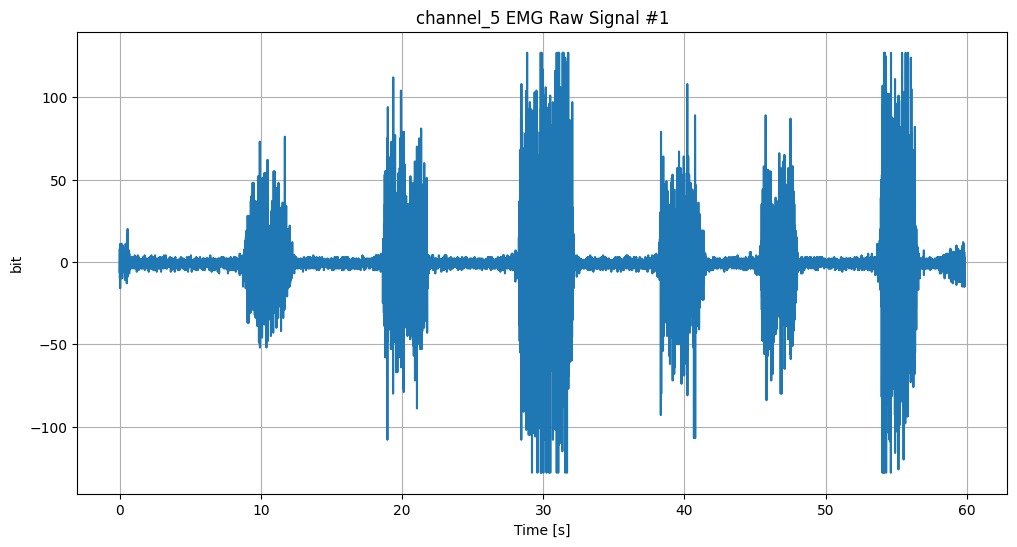

In [9]:
for i in range(len(emg_time)):
    emg_signal = muscle_emg_raw[channel_ref][i]
    time_vector = emg_time[i]
    plot_emg_signal(emg_signal, time_vector, title=f"{channel_ref} EMG Raw Signal #{i+1}", ylabel="bit")

# EMG Signal Analysis

## Filtering, Rectification, Smoothing and Normalization

In [10]:
for time in emg_time:
    fs = 1.0 / np.mean(np.diff(time))  # Calculate sampling frequency from time intervals
    windows_idx = [(int(fs * start), int(fs * end)) for start, end in windows_s] # Convert to indices using sampling frequency
    windows_idx_list.append(windows_idx)
    fs_list.append(fs) 
fs_list_ext = [fs for fs in fs_list for _ in range(n_segments)]

In [11]:
muscle_emg_filtered, _, _, muscle_emg_normalized = emg_filters(muscle_emg_raw, emg_time, fs_list, channel_names, mvc)

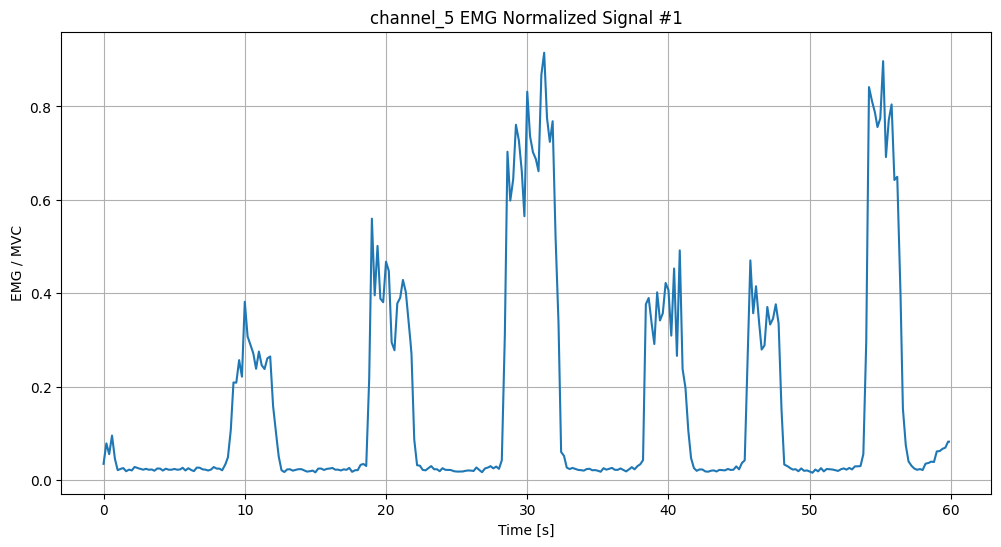

In [12]:
for i in range(len(emg_time)):
    emg_signal = muscle_emg_normalized[channel_ref][i]
    time_vector = emg_time[i]
    plot_emg_signal(emg_signal, time_vector, title=f"{channel_ref} EMG Normalized Signal #{i+1}", ylabel="EMG / MVC")

# IMU Signal Analysis

In [13]:
from imu_utils import (plot_imu_signals, detect_segments_imu, process_imu_segments, extract_imu_windows, extract_imu_features, compute_vm_features, 
                        align_imu_signals_trigno, plot_imu_myo, plot_imu_segmented_myo, detect_segments_imu_myo, process_imu_myo, 
                        extract_imu_windows_myo, extract_imu_features_myo, compute_vm_features_myo)
from myo_utils import myo_extract_imu_py

In [15]:
imu_myo, imu_time_myo, fs_imu_list_myo = myo_extract_imu_py(dataframes)

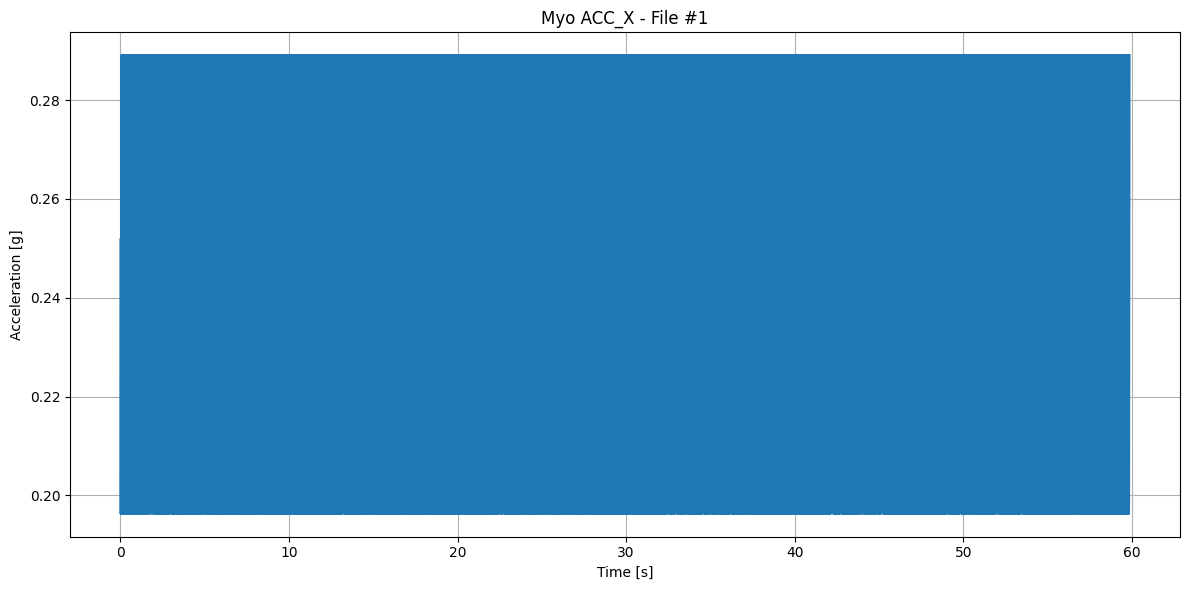

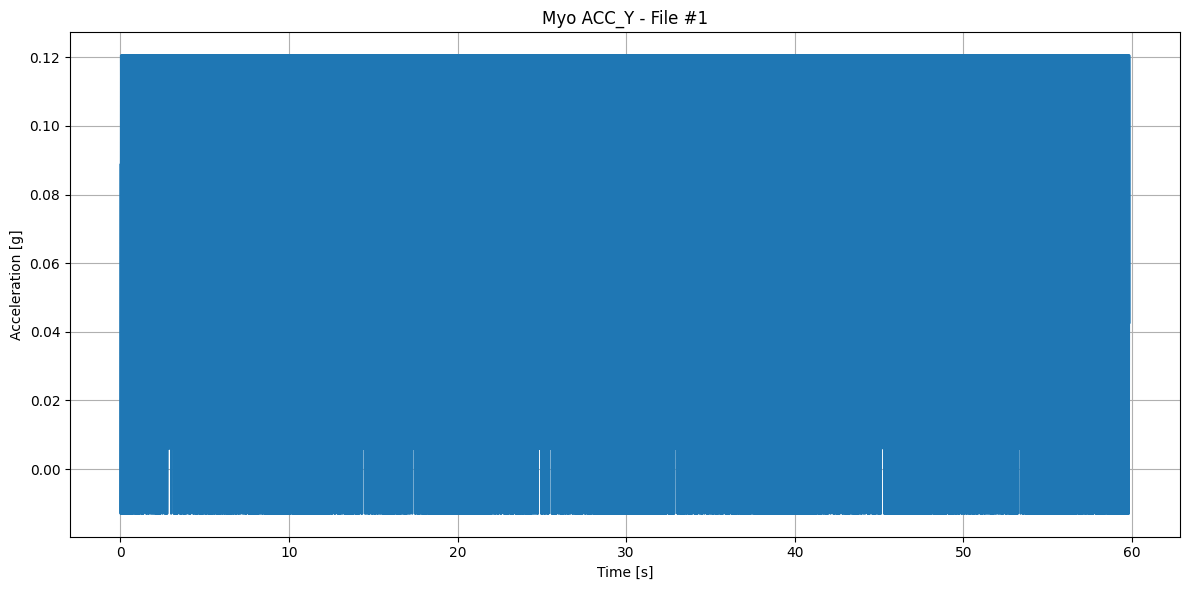

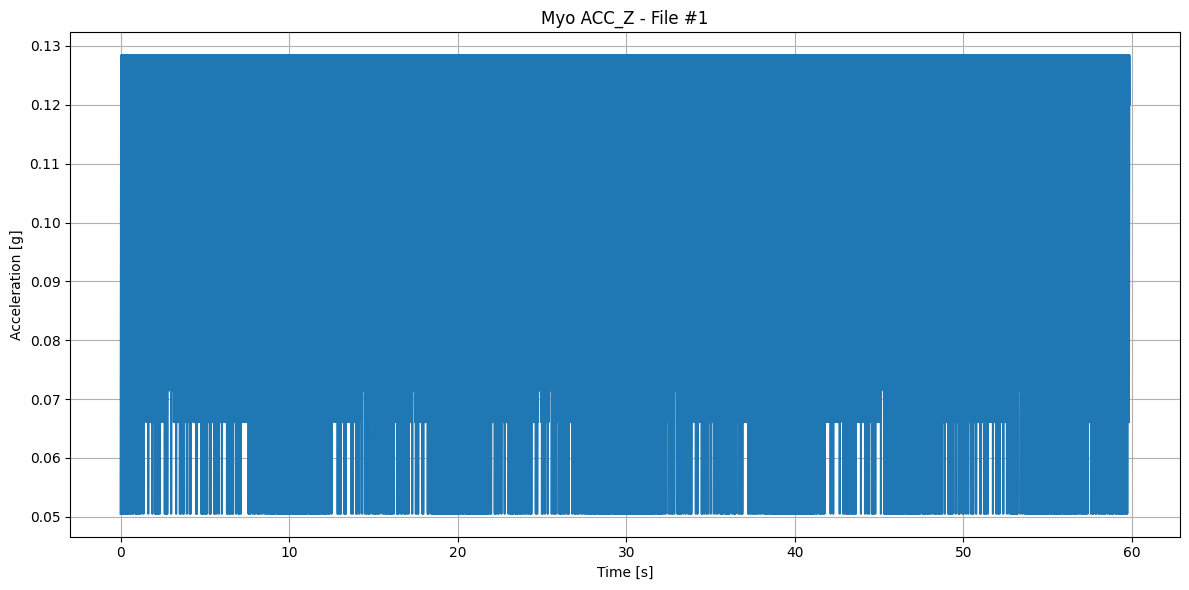

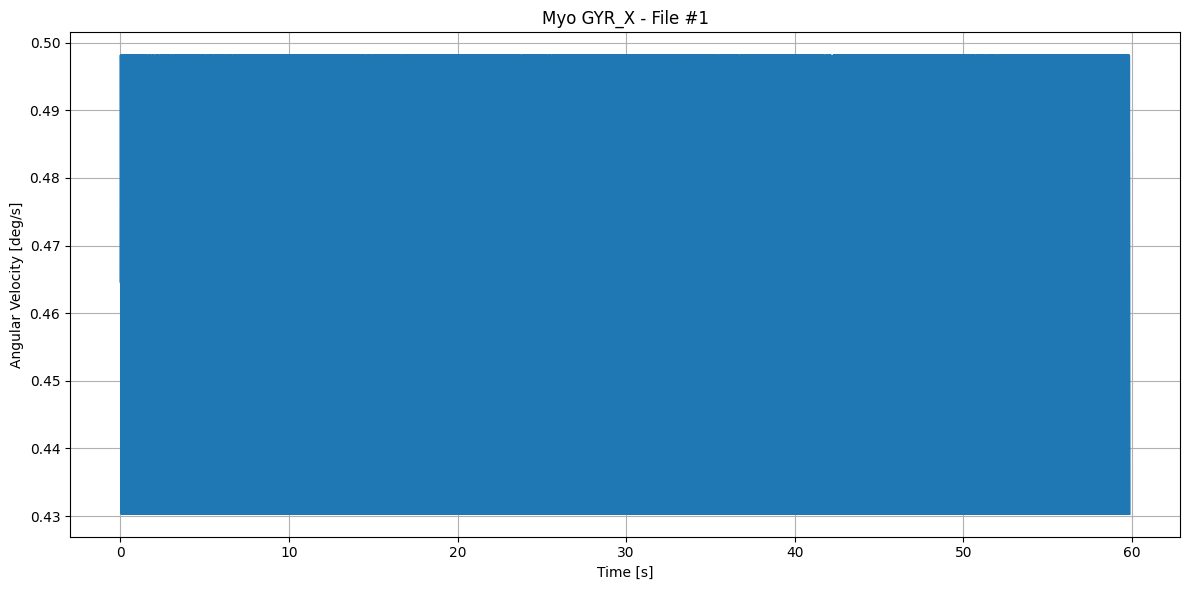

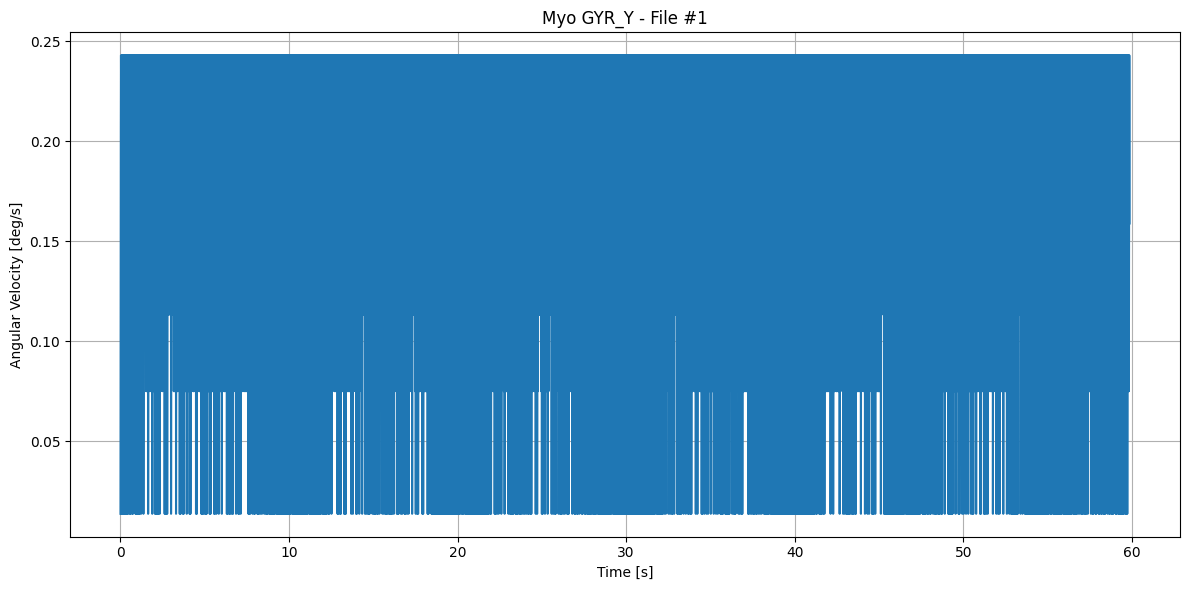

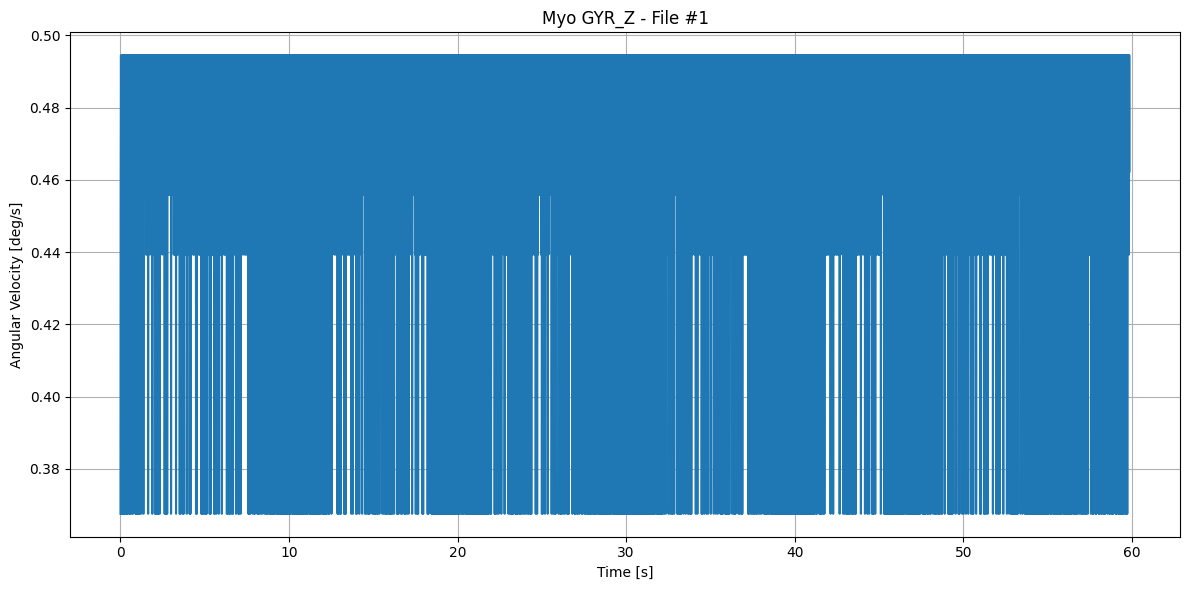

KeyError: 'roll'

In [17]:
plot_imu_myo(imu_myo, imu_time_myo)  # Plot raw IMU signals from Myo 

In [13]:
for i in range(len(imu_time_myo)):
    fs_myo = fs_imu_list_myo[i] # Sampling frequency per trial
    windows_idx = [(int(fs_myo * start), int(fs_myo * end)) for start, end in windows_s] # Convert time windows to index ranges
    windows_idx_imu_list_myo.append(windows_idx) # Store window indices list

NameError: name 'imu_time_myo' is not defined

In [14]:
# Segment raw Myo IMU data and corresponding time arrays based on window indices
imu_myo_raw_cut, imu_myo_times_cut = detect_segments_imu_myo(imu_time_myo, imu_myo, windows_idx_imu_list_myo, fs_imu_list_myo)

NameError: name 'detect_segments_imu_myo' is not defined

In [ ]:
plot_imu_segmented_myo(imu_myo_raw_cut, imu_myo_times_cut, flag=True) # Plot segmented Myo IMU data 

In [ ]:
# Process raw segmented Myo IMU data by applying filtering and preprocessing with specified cutoff frequency
imu_processed_myo = process_imu_myo(imu_myo_raw_cut, imu_myo_times_cut, cutoff_imu)

In [ ]:
# Adjust breakpoint indices to actual time values considering segment offset, then plot processed Myo IMU data with breakpoints shown
bkps_times = [[idx / fs_emg_list_ext_myo[i] + 130 * i for idx in segment] for i, segment in enumerate(breakpoints_myo)]
plot_imu_segmented_myo(imu_processed_myo, imu_myo_times_cut, flag=False, breakpoints_times=bkps_times)

## Windowing and Features Extraction

In [12]:
emg_norm_cut, emg_filt_cut, emg_time_cut, breakpoints = detect_segments_v2(
    emg_time, muscle_emg_normalized, muscle_emg_filtered, channel_names, channel_ref, windows_idx_list, intensity_level, n_lifts, fs_list, flag=True)

In [11]:
normalized_win, filtered_win, time_win = extract_emg_windows_v2(emg_norm_cut, emg_filt_cut, emg_time_cut, fs_list_ext, 
                                                                window_duration=w_d, overlap=ov)

In [12]:
# Features Extraction
time_features_norm = extract_emg_features(normalized_win, features_list_norm)  # Extract time-domain features from normalized EMG windows
time_features_filt = extract_emg_features(filtered_win, features_list_filt)  # Extract time-domain features from filtered EMG windows
freq_features_norm = extract_emg_features(normalized_win, features_list_freq)  # Extract frequency-domain features from normalized EMG windows 

In [13]:
dfs = combine_multiple_features_lists(time_features_norm, time_features_filt, freq_features_norm)  # Combine all feature lists into a single dataframe

## Label Assignment

In [15]:
dfs['label'] = assign_emg_labels_v2(breakpoints, windows_per_segment, fs_list_ext, w_d, ov, intensity_level, n_lifts)

# Features Export

In [17]:
output_path = os.path.join(output_folder, output_filename)  # Create full path for output CSV file
dfs.to_csv(output_path, index=False)  # Save dataframe with features and labels to CSV